# Virtual Try-On Evaluation without Ground Truth

This notebook evaluates virtual try-on results in a **no-ground-truth** setting.

You only need three images:

```text
1. Original person image
2. Target garment image
3. Generated try-on output
```

The notebook computes:

| Metric | Comparison | Direction |
|---|---|---|
| Face Embedding Similarity | original person face vs generated face | higher is better |
| CLIP Style Category Consistency | original person image vs generated image | higher is better |
| VGG Gram Texture Distance | target garment vs generated garment region | lower is better |
| Color Histogram Distance | target garment vs generated garment region | lower is better |
| DINOv2 Garment Similarity | target garment vs generated garment region | higher is better |

Important: the garment-related metrics depend strongly on the garment masks. Please check the mask visualization before trusting the scores.

In [1]:
# =========================
# 1. Install dependencies
# =========================

!pip -q install "pandas==2.2.2" "pillow>=8.0,<12.0" "scikit-image>=0.19,<0.26"
!pip -q install "transformers>=4.40,<5.0" "accelerate>=0.25" "timm>=0.9" "opencv-python" "insightface" "onnxruntime"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 21.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 17.0 MB/s eta 0:00:00


In [2]:
# =========================
# 2. Mount Google Drive
# =========================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# 3. Set your image paths
# =========================
# Change these three paths to your own Google Drive image paths.

PERSON_PATH = "/content/drive/MyDrive/DL/evalution/model_1.png"       # original person image
GARMENT_PATH = "/content/drive/MyDrive/DL/evalution/2.jpg"     # target garment image
OUTPUT_PATH = "/content/drive/MyDrive/DL/evalution/resultshort.png"       # generated try-on result

# Evaluation output folder
SAVE_DIR = "/content/drive/MyDrive/DL/TaskB/eval_results"

# Garment type controls the CLIPSeg prompts used for automatic garment masking.
# Options: "upper", "lower", "dress", "general"
GARMENT_TYPE = "general"

# CLIPSeg threshold:
# - If the garment mask is too small, reduce it, e.g. 0.25 or 0.30
# - If the garment mask is too large, increase it, e.g. 0.40 or 0.45
CLIPSEG_THRESHOLD = 0.35

Using device: cuda
Person image size: (768, 1024)
Garment image size: (768, 1024)
Output image size: (768, 1024)


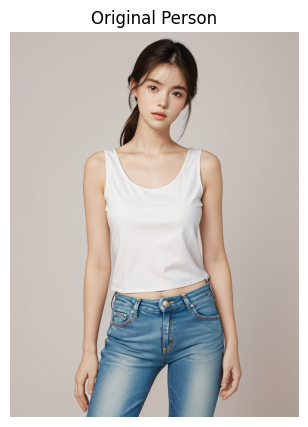

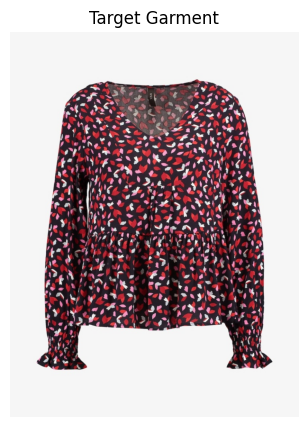

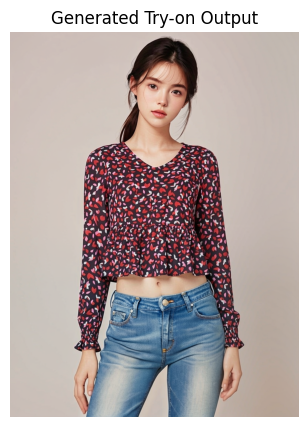

In [4]:
# =========================
# 4. Imports and basic utilities
# =========================

import os
import cv2
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

os.makedirs(SAVE_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


def load_rgb(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image path does not exist: {path}")
    return Image.open(path).convert("RGB")


def pil_to_cv2_bgr(pil_img):
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)


def show_image(title, img, cmap=None, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis("off")
    plt.show()


person_img = load_rgb(PERSON_PATH)
garment_img = load_rgb(GARMENT_PATH)
output_img = load_rgb(OUTPUT_PATH)

print("Person image size:", person_img.size)
print("Garment image size:", garment_img.size)
print("Output image size:", output_img.size)

show_image("Original Person", person_img)
show_image("Target Garment", garment_img)
show_image("Generated Try-on Output", output_img)

In [5]:
# =========================
# 5. Garment prompts for CLIPSeg
# =========================

PROMPT_BANK = {
    "upper": [
        "shirt",
        "top",
        "upper body clothing",
        "jacket",
        "sweater",
        "blouse",
        "coat",
        "hoodie"
    ],
    "lower": [
        "pants",
        "trousers",
        "skirt",
        "shorts",
        "jeans",
        "lower body clothing"
    ],
    "dress": [
        "dress",
        "long dress",
        "one-piece dress",
        "gown"
    ],
    "general": [
        "clothing",
        "garment",
        "shirt",
        "top",
        "jacket",
        "dress",
        "pants",
        "skirt"
    ],
}

if GARMENT_TYPE not in PROMPT_BANK:
    raise ValueError(f"GARMENT_TYPE must be one of {list(PROMPT_BANK.keys())}")

GARMENT_PROMPTS = PROMPT_BANK[GARMENT_TYPE]
print("Using garment prompts:", GARMENT_PROMPTS)

Using garment prompts: ['clothing', 'garment', 'shirt', 'top', 'jacket', 'dress', 'pants', 'skirt']


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils.py:51: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)


Target garment bbox: (np.int64(65), np.int64(104), np.int64(699), np.int64(919))
Generated garment bbox: (np.int64(156), np.int64(265), np.int64(637), 1023)


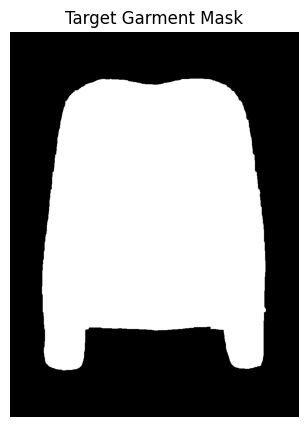

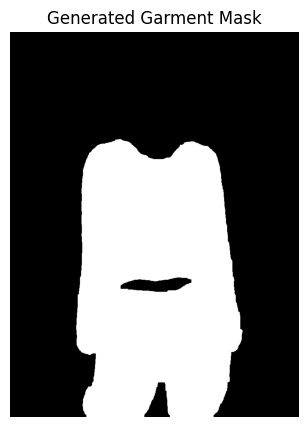

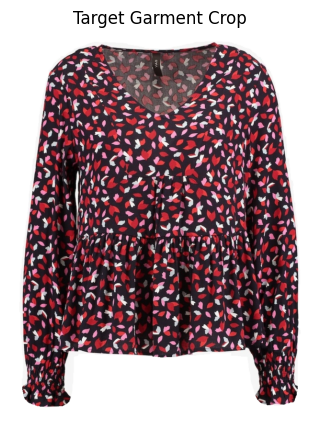

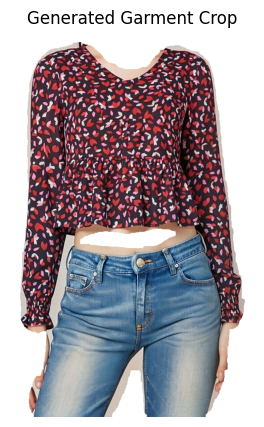

Saved garment masks and crops to: /content/drive/MyDrive/DL/TaskB/eval_results


In [6]:
# =========================
# 6. Automatic garment masking with CLIPSeg
# =========================

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

clipseg_processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
clipseg_model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined").to(device)
clipseg_model.eval()


def postprocess_mask(mask, min_area_ratio=0.002):
    # Clean a binary mask using morphology and connected components.
    # mask: uint8 array, values 0/1
    mask = mask.astype(np.uint8)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    h, w = mask.shape
    min_area = h * w * min_area_ratio

    cleaned = np.zeros_like(mask)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == i] = 1

    return cleaned


def clipseg_garment_mask(pil_img, prompts, threshold=0.35):
    # Use CLIPSeg to extract garment mask from an image.
    w, h = pil_img.size
    images = [pil_img] * len(prompts)

    inputs = clipseg_processor(
        text=prompts,
        images=images,
        padding=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = clipseg_model(**inputs)

    logits = outputs.logits
    probs = torch.sigmoid(logits)

    probs = F.interpolate(
        probs.unsqueeze(1),
        size=(h, w),
        mode="bilinear",
        align_corners=False
    ).squeeze(1)

    combined = probs.max(dim=0).values
    combined_np = combined.detach().cpu().numpy()

    mask = (combined_np >= threshold).astype(np.uint8)
    mask = postprocess_mask(mask)

    return mask, combined_np


def mask_to_bbox(mask, pad=10):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None

    h, w = mask.shape
    x1 = max(xs.min() - pad, 0)
    y1 = max(ys.min() - pad, 0)
    x2 = min(xs.max() + pad, w - 1)
    y2 = min(ys.max() + pad, h - 1)

    return x1, y1, x2, y2


def crop_with_mask_white_bg(pil_img, mask, pad=10):
    # Crop garment region using mask and set non-garment pixels to white.
    arr = np.array(pil_img).copy()
    bbox = mask_to_bbox(mask, pad=pad)

    if bbox is None:
        raise ValueError("Mask is empty. Try lowering CLIPSEG_THRESHOLD.")

    white = np.ones_like(arr) * 255
    arr_masked = np.where(mask[..., None] > 0, arr, white)

    x1, y1, x2, y2 = bbox
    crop = arr_masked[y1:y2+1, x1:x2+1]

    return Image.fromarray(crop), bbox


garment_mask, garment_prob = clipseg_garment_mask(
    garment_img,
    GARMENT_PROMPTS,
    threshold=CLIPSEG_THRESHOLD
)

output_garment_mask, output_garment_prob = clipseg_garment_mask(
    output_img,
    GARMENT_PROMPTS,
    threshold=CLIPSEG_THRESHOLD
)

garment_crop, garment_bbox = crop_with_mask_white_bg(garment_img, garment_mask, pad=20)
output_garment_crop, output_garment_bbox = crop_with_mask_white_bg(output_img, output_garment_mask, pad=20)

print("Target garment bbox:", garment_bbox)
print("Generated garment bbox:", output_garment_bbox)

show_image("Target Garment Mask", garment_mask, cmap="gray")
show_image("Generated Garment Mask", output_garment_mask, cmap="gray")
show_image("Target Garment Crop", garment_crop)
show_image("Generated Garment Crop", output_garment_crop)

Image.fromarray((garment_mask * 255).astype(np.uint8)).save(os.path.join(SAVE_DIR, "target_garment_mask.png"))
Image.fromarray((output_garment_mask * 255).astype(np.uint8)).save(os.path.join(SAVE_DIR, "generated_garment_mask.png"))
garment_crop.save(os.path.join(SAVE_DIR, "target_garment_crop.png"))
output_garment_crop.save(os.path.join(SAVE_DIR, "generated_garment_crop.png"))

print("Saved garment masks and crops to:", SAVE_DIR)

## Optional: If the automatic garment mask is bad

Change these settings and rerun Cell 5 and Cell 6:

```python
GARMENT_TYPE = "upper"   # upper / lower / dress / general
CLIPSEG_THRESHOLD = 0.30 # lower = larger mask, higher = smaller mask
```

Garment-related metrics are only meaningful if the garment masks are reasonable.

In [7]:
# =========================
# 7. Face Embedding Similarity
# =========================
# Comparison: original person face vs generated face.
# Higher is better.

from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

face_app.prepare(
    ctx_id=0 if device == "cuda" else -1,
    det_size=(640, 640)
)


def get_largest_face_embedding(pil_img):
    bgr = pil_to_cv2_bgr(pil_img)
    faces = face_app.get(bgr)

    if len(faces) == 0:
        return None, None

    def face_area(face):
        x1, y1, x2, y2 = face.bbox
        return max(0, x2 - x1) * max(0, y2 - y1)

    face = max(faces, key=face_area)

    if hasattr(face, "normed_embedding"):
        emb = face.normed_embedding
    else:
        emb = face.embedding
        emb = emb / (np.linalg.norm(emb) + 1e-8)

    return emb.astype(np.float32), face.bbox


def cosine_np(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def face_embedding_similarity(person_img, output_img):
    emb_p, bbox_p = get_largest_face_embedding(person_img)
    emb_o, bbox_o = get_largest_face_embedding(output_img)

    if emb_p is None or emb_o is None:
        return np.nan, bbox_p, bbox_o

    sim = cosine_np(emb_p, emb_o)
    return sim, bbox_p, bbox_o


face_sim, face_bbox_person, face_bbox_output = face_embedding_similarity(person_img, output_img)

print("Face Embedding Similarity ↑:", face_sim)
print("Person face bbox:", face_bbox_person)
print("Generated face bbox:", face_bbox_output)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 95526.83KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Face Embeddi

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP Style JS Similarity ↑: 0.9961709671483009
Original person top style: an e-commerce clothing model photo
Generated output top style: an e-commerce clothing model photo
Top style match: True


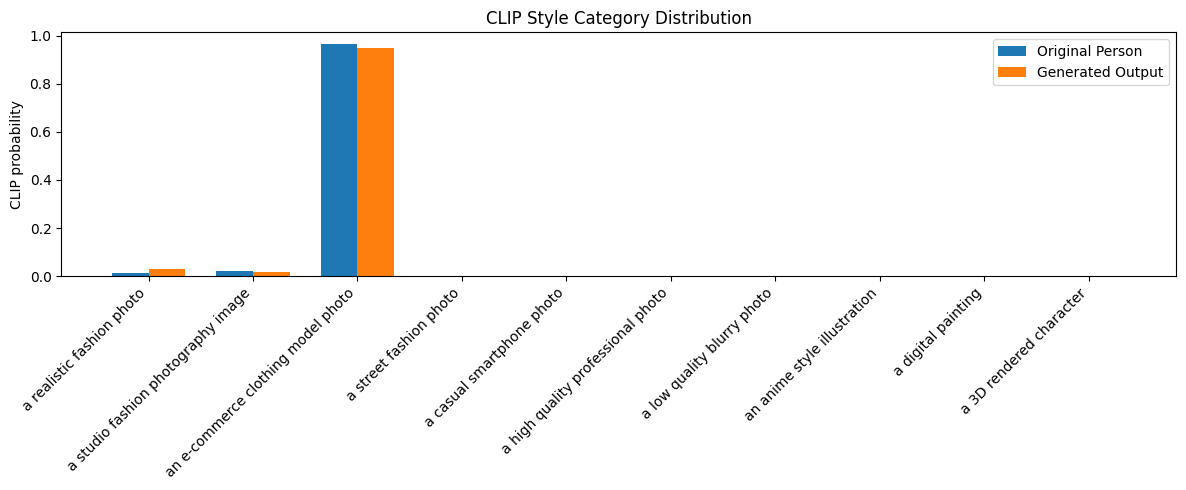

Saved style distribution figure to: /content/drive/MyDrive/DL/TaskB/eval_results/clip_style_distribution.png


In [8]:
# =========================
# 8. CLIP Style Category Consistency
# =========================
# Comparison: original person image vs generated output.
# Higher JS similarity is better.
# Top style match = True means both images are classified into the same highest-probability style category.

from transformers import CLIPProcessor, CLIPModel

clip_model_id = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_model.eval()


STYLE_PROMPTS = [
    "a realistic fashion photo",
    "a studio fashion photography image",
    "an e-commerce clothing model photo",
    "a street fashion photo",
    "a casual smartphone photo",
    "a high quality professional photo",
    "a low quality blurry photo",
    "an anime style illustration",
    "a digital painting",
    "a 3D rendered character"
]


def clip_style_distribution(pil_img, style_prompts):
    inputs = clip_processor(
        text=style_prompts,
        images=pil_img,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)

    logits = outputs.logits_per_image.squeeze(0)
    probs = torch.softmax(logits, dim=-1)

    return probs.detach().cpu().numpy()


def js_similarity(p, q, eps=1e-8):
    # Jensen-Shannon similarity.
    # Higher means the two style distributions are more similar.
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    p = p / (p.sum() + eps)
    q = q / (q.sum() + eps)
    m = 0.5 * (p + q)

    kl_pm = np.sum(p * np.log((p + eps) / (m + eps)))
    kl_qm = np.sum(q * np.log((q + eps) / (m + eps)))

    js = 0.5 * (kl_pm + kl_qm)
    js_norm = js / np.log(2.0)

    return float(1.0 - js_norm)


def clip_style_consistency(person_img, output_img):
    p_style = clip_style_distribution(person_img, STYLE_PROMPTS)
    o_style = clip_style_distribution(output_img, STYLE_PROMPTS)

    sim = js_similarity(p_style, o_style)

    p_top = int(np.argmax(p_style))
    o_top = int(np.argmax(o_style))

    result = {
        "clip_style_js_similarity": sim,
        "person_top_style": STYLE_PROMPTS[p_top],
        "output_top_style": STYLE_PROMPTS[o_top],
        "top_style_match": STYLE_PROMPTS[p_top] == STYLE_PROMPTS[o_top],
        "person_style_distribution": p_style,
        "output_style_distribution": o_style,
    }

    return result


style_result = clip_style_consistency(person_img, output_img)

print("CLIP Style JS Similarity ↑:", style_result["clip_style_js_similarity"])
print("Original person top style:", style_result["person_top_style"])
print("Generated output top style:", style_result["output_top_style"])
print("Top style match:", style_result["top_style_match"])


def plot_style_distribution(style_result):
    p = style_result["person_style_distribution"]
    o = style_result["output_style_distribution"]

    x = np.arange(len(STYLE_PROMPTS))
    width = 0.35

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, p, width, label="Original Person")
    plt.bar(x + width / 2, o, width, label="Generated Output")
    plt.xticks(x, STYLE_PROMPTS, rotation=45, ha="right")
    plt.ylabel("CLIP probability")
    plt.title("CLIP Style Category Distribution")
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, "clip_style_distribution.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved style distribution figure to:", save_path)


plot_style_distribution(style_result)

In [9]:
# =========================
# 9. VGG Gram Matrix Texture Distance
# =========================
# Comparison: target garment crop vs generated garment crop.
# Lower is better.

from torchvision.models import vgg19, VGG19_Weights

vgg_weights = VGG19_Weights.IMAGENET1K_V1
vgg = vgg19(weights=vgg_weights).features.to(device).eval()

for p in vgg.parameters():
    p.requires_grad = False


# Common style/texture layers in VGG19.
VGG_LAYERS = {
    "relu1_1": 1,
    "relu2_1": 6,
    "relu3_1": 11,
    "relu4_1": 20,
}


vgg_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def image_to_vgg_tensor(pil_img):
    return vgg_transform(pil_img).unsqueeze(0).to(device)


def extract_vgg_features(x, layers=VGG_LAYERS):
    features = {}
    current = x

    max_layer = max(layers.values())

    for i, layer in enumerate(vgg):
        current = layer(current)

        for name, idx in layers.items():
            if i == idx:
                features[name] = current

        if i >= max_layer:
            break

    return features


def gram_matrix(feat):
    # feat: [B, C, H, W]
    b, c, h, w = feat.shape
    f = feat.view(b, c, h * w)
    gram = torch.bmm(f, f.transpose(1, 2))
    gram = gram / (c * h * w)
    return gram


def vgg_gram_texture_distance(img_a, img_b):
    # Gram Matrix L1 distance.
    # Lower means more similar global texture.
    xa = image_to_vgg_tensor(img_a)
    xb = image_to_vgg_tensor(img_b)

    with torch.no_grad():
        fa = extract_vgg_features(xa)
        fb = extract_vgg_features(xb)

        layer_distances = {}
        total = 0.0

        for layer_name in VGG_LAYERS.keys():
            ga = gram_matrix(fa[layer_name])
            gb = gram_matrix(fb[layer_name])

            dist = torch.mean(torch.abs(ga - gb)).item()
            layer_distances[layer_name] = dist
            total += dist

    avg_dist = total / len(VGG_LAYERS)

    return avg_dist, layer_distances


texture_dist, texture_layer_distances = vgg_gram_texture_distance(
    garment_crop,
    output_garment_crop
)

print("VGG Gram Texture Distance ↓:", texture_dist)
print("Layer distances:")
for k, v in texture_layer_distances.items():
    print(f"{k}: {v}")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 66.4MB/s]


VGG Gram Texture Distance ↓: 0.00443703425116837
Layer distances:
relu1_1: 0.0016475408338010311
relu2_1: 0.004988044500350952
relu3_1: 0.007737199775874615
relu4_1: 0.003375351894646883


In [10]:
# =========================
# 10. Color Histogram Distance
# =========================
# Comparison: target garment region vs generated garment region.
# Lower is better.
#
# We use HSV H-S histogram and Bhattacharyya distance.

def hsv_histogram_distance(pil_img_a, mask_a, pil_img_b, mask_b):
    arr_a = cv2.cvtColor(np.array(pil_img_a), cv2.COLOR_RGB2HSV)
    arr_b = cv2.cvtColor(np.array(pil_img_b), cv2.COLOR_RGB2HSV)

    mask_a_uint8 = (mask_a > 0).astype(np.uint8) * 255
    mask_b_uint8 = (mask_b > 0).astype(np.uint8) * 255

    hist_a = cv2.calcHist(
        [arr_a],
        channels=[0, 1],
        mask=mask_a_uint8,
        histSize=[32, 32],
        ranges=[0, 180, 0, 256]
    )

    hist_b = cv2.calcHist(
        [arr_b],
        channels=[0, 1],
        mask=mask_b_uint8,
        histSize=[32, 32],
        ranges=[0, 180, 0, 256]
    )

    hist_a = cv2.normalize(hist_a, hist_a).flatten()
    hist_b = cv2.normalize(hist_b, hist_b).flatten()

    distance = cv2.compareHist(hist_a, hist_b, cv2.HISTCMP_BHATTACHARYYA)

    return float(distance)


color_hist_dist = hsv_histogram_distance(
    garment_img,
    garment_mask,
    output_img,
    output_garment_mask
)

print("Color Histogram Distance ↓:", color_hist_dist)

Color Histogram Distance ↓: 0.4961112200747138


In [11]:
# =========================
# 11. DINOv2 Garment Similarity
# =========================
# Comparison: target garment crop vs generated garment crop.
#
# DINOv2 CLS similarity: global garment visual similarity.
# DINOv2 patch similarity: local detail similarity.
#
# Higher is better.

from transformers import AutoImageProcessor, AutoModel

dinov2_model_id = "facebook/dinov2-base"

dinov2_processor = AutoImageProcessor.from_pretrained(dinov2_model_id)
dinov2_model = AutoModel.from_pretrained(dinov2_model_id).to(device)
dinov2_model.eval()


def dinov2_features(pil_img):
    inputs = dinov2_processor(images=pil_img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = dinov2_model(**inputs)

    # last_hidden_state: [B, 1 + num_patches, C]
    tokens = outputs.last_hidden_state

    cls_token = tokens[:, 0, :]      # [B, C]
    patch_tokens = tokens[:, 1:, :]  # [B, N, C]

    cls_token = F.normalize(cls_token, dim=-1)
    patch_tokens = F.normalize(patch_tokens, dim=-1)

    return cls_token, patch_tokens


def dinov2_garment_similarity(img_a, img_b):
    cls_a, patch_a = dinov2_features(img_a)
    cls_b, patch_b = dinov2_features(img_b)

    # Global CLS similarity
    cls_sim = torch.sum(cls_a * cls_b, dim=-1).item()

    # Patch-level matching:
    # For each target garment patch, find the most similar generated garment patch.
    sim_matrix = torch.matmul(patch_a, patch_b.transpose(1, 2))  # [B, Na, Nb]
    best_sim_a_to_b = sim_matrix.max(dim=-1).values              # [B, Na]
    patch_sim = best_sim_a_to_b.mean().item()

    return float(cls_sim), float(patch_sim)


dino_cls_sim, dino_patch_sim = dinov2_garment_similarity(
    garment_crop,
    output_garment_crop
)

print("DINOv2 CLS Garment Similarity ↑:", dino_cls_sim)
print("DINOv2 Patch Garment Similarity ↑:", dino_patch_sim)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

DINOv2 CLS Garment Similarity ↑: 0.667536735534668
DINOv2 Patch Garment Similarity ↑: 0.7738662958145142


In [12]:
# =========================
# 11.1 DINOv2 Local Detail Statistics
# =========================
# More sensitive to local garment detail loss.
# Higher is better.

def dinov2_patch_detail_stats(img_a, img_b):
    """
    img_a: target garment crop
    img_b: generated garment crop

    For every patch in the target garment, find the best matching patch
    in the generated garment. Then report mean / low-percentile / coverage.
    """
    cls_a, patch_a = dinov2_features(img_a)
    cls_b, patch_b = dinov2_features(img_b)

    sim_matrix = torch.matmul(patch_a, patch_b.transpose(1, 2))  # [B, Na, Nb]
    best_sim = sim_matrix.max(dim=-1).values.squeeze(0)          # [Na]

    best_sim_np = best_sim.detach().cpu().numpy()

    stats = {
        "DINO Patch Mean Similarity ↑": float(np.mean(best_sim_np)),
        "DINO Patch P10 Similarity ↑": float(np.percentile(best_sim_np, 10)),
        "DINO Patch P25 Similarity ↑": float(np.percentile(best_sim_np, 25)),
        "DINO Patch Median Similarity ↑": float(np.percentile(best_sim_np, 50)),
        "DINO Patch Coverage@0.60 ↑": float(np.mean(best_sim_np >= 0.60)),
        "DINO Patch Coverage@0.70 ↑": float(np.mean(best_sim_np >= 0.70)),
        "DINO Patch Coverage@0.75 ↑": float(np.mean(best_sim_np >= 0.75)),
    }

    return stats


dino_detail_stats = dinov2_patch_detail_stats(
    garment_crop,
    output_garment_crop
)

for k, v in dino_detail_stats.items():
    print(k, ":", v)

DINO Patch Mean Similarity ↑ : 0.7738662958145142
DINO Patch P10 Similarity ↑ : 0.6515271663665771
DINO Patch P25 Similarity ↑ : 0.7281001806259155
DINO Patch Median Similarity ↑ : 0.7835032939910889
DINO Patch Coverage@0.60 ↑ : 0.95703125
DINO Patch Coverage@0.70 ↑ : 0.84765625
DINO Patch Coverage@0.75 ↑ : 0.671875


In [13]:
# =========================
# 11.2 Local Feature Matching for Logo / Pattern Details
# =========================
# This is more sensitive to logos, text, printed patterns, stripes, and local decorations.
# Higher good_matches / inlier_ratio / match_coverage usually means better local detail preservation.

def prepare_gray_for_matching(pil_img, size=512):
    """
    Convert image to grayscale and resize for local feature matching.
    """
    img = np.array(pil_img.convert("RGB"))
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Improve local contrast, useful for logos / text / patterns.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    return gray


def create_local_detector(method="SIFT"):
    """
    Prefer SIFT if available. Fall back to ORB otherwise.
    """
    method = method.upper()

    if method == "SIFT" and hasattr(cv2, "SIFT_create"):
        detector = cv2.SIFT_create(nfeatures=2000)
        norm_type = cv2.NORM_L2
        descriptor_type = "float"
        actual_method = "SIFT"
    else:
        detector = cv2.ORB_create(nfeatures=2000)
        norm_type = cv2.NORM_HAMMING
        descriptor_type = "binary"
        actual_method = "ORB"

    return detector, norm_type, descriptor_type, actual_method


def local_feature_match_score(img_a, img_b, method="SIFT", ratio_thresh=0.75):
    """
    img_a: target garment crop
    img_b: generated garment crop

    Returns local matching metrics.
    Higher is better.
    """
    gray_a = prepare_gray_for_matching(img_a, size=512)
    gray_b = prepare_gray_for_matching(img_b, size=512)

    detector, norm_type, descriptor_type, actual_method = create_local_detector(method)

    kp_a, des_a = detector.detectAndCompute(gray_a, None)
    kp_b, des_b = detector.detectAndCompute(gray_b, None)

    result = {
        "Local Match Method": actual_method,
        "Target Keypoints": 0 if kp_a is None else len(kp_a),
        "Generated Keypoints": 0 if kp_b is None else len(kp_b),
        "Good Matches ↑": 0,
        "Inlier Matches ↑": 0,
        "Inlier Ratio ↑": 0.0,
        "Match Coverage ↑": 0.0,
    }

    if des_a is None or des_b is None or len(kp_a) < 4 or len(kp_b) < 4:
        return result

    if descriptor_type == "float":
        matcher = cv2.BFMatcher(norm_type)
        knn_matches = matcher.knnMatch(des_a, des_b, k=2)

        good = []
        for m_n in knn_matches:
            if len(m_n) < 2:
                continue
            m, n = m_n
            if m.distance < ratio_thresh * n.distance:
                good.append(m)

    else:
        matcher = cv2.BFMatcher(norm_type, crossCheck=True)
        good = matcher.match(des_a, des_b)
        good = sorted(good, key=lambda x: x.distance)

        # Keep better half of ORB matches to reduce noise.
        good = good[: max(1, len(good) // 2)]

    result["Good Matches ↑"] = len(good)

    if len(good) >= 4:
        pts_a = np.float32([kp_a[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        pts_b = np.float32([kp_b[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inlier_mask = cv2.findHomography(
            pts_a,
            pts_b,
            cv2.RANSAC,
            ransacReprojThreshold=5.0
        )

        if inlier_mask is not None:
            inliers = int(inlier_mask.sum())
        else:
            inliers = 0

        result["Inlier Matches ↑"] = inliers
        result["Inlier Ratio ↑"] = float(inliers / max(len(good), 1))
        result["Match Coverage ↑"] = float(inliers / max(len(kp_a), 1))

    return result


local_match_stats = local_feature_match_score(
    garment_crop,
    output_garment_crop,
    method="SIFT"
)

for k, v in local_match_stats.items():
    print(k, ":", v)

Local Match Method : SIFT
Target Keypoints : 2000
Generated Keypoints : 2000
Good Matches ↑ : 161
Inlier Matches ↑ : 58
Inlier Ratio ↑ : 0.36024844720496896
Match Coverage ↑ : 0.029


In [14]:
# =========================
# 12. Save all metrics
# =========================

from datetime import datetime

results = {
    "eval_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "person_path": PERSON_PATH,
    "garment_path": GARMENT_PATH,
    "output_path": OUTPUT_PATH,
    "garment_type": GARMENT_TYPE,
    "clipseg_threshold": CLIPSEG_THRESHOLD,

    "Face Embedding Similarity ↑": face_sim,

    "CLIP Style JS Similarity ↑": style_result["clip_style_js_similarity"],
    "CLIP Top Style Match": style_result["top_style_match"],
    "Original Top Style": style_result["person_top_style"],
    "Generated Top Style": style_result["output_top_style"],

    "VGG Gram Texture Distance ↓": texture_dist,
    "VGG relu1_1 Distance ↓": texture_layer_distances["relu1_1"],
    "VGG relu2_1 Distance ↓": texture_layer_distances["relu2_1"],
    "VGG relu3_1 Distance ↓": texture_layer_distances["relu3_1"],
    "VGG relu4_1 Distance ↓": texture_layer_distances["relu4_1"],

    "Color Histogram Distance ↓": color_hist_dist,

    "DINOv2 CLS Garment Similarity ↑": dino_cls_sim,
    "DINOv2 Patch Garment Similarity ↑": dino_patch_sim,

    # More sensitive DINO local detail metrics
    "DINO Patch Mean Similarity ↑": dino_detail_stats["DINO Patch Mean Similarity ↑"],
    "DINO Patch P10 Similarity ↑": dino_detail_stats["DINO Patch P10 Similarity ↑"],
    "DINO Patch P25 Similarity ↑": dino_detail_stats["DINO Patch P25 Similarity ↑"],
    "DINO Patch Median Similarity ↑": dino_detail_stats["DINO Patch Median Similarity ↑"],
    "DINO Patch Coverage@0.60 ↑": dino_detail_stats["DINO Patch Coverage@0.60 ↑"],
    "DINO Patch Coverage@0.70 ↑": dino_detail_stats["DINO Patch Coverage@0.70 ↑"],
    "DINO Patch Coverage@0.75 ↑": dino_detail_stats["DINO Patch Coverage@0.75 ↑"],

    # Local feature matching for logo / text / pattern
    "Local Match Method": local_match_stats["Local Match Method"],
    "Target Keypoints": local_match_stats["Target Keypoints"],
    "Generated Keypoints": local_match_stats["Generated Keypoints"],
    "Good Matches ↑": local_match_stats["Good Matches ↑"],
    "Inlier Matches ↑": local_match_stats["Inlier Matches ↑"],
    "Inlier Ratio ↑": local_match_stats["Inlier Ratio ↑"],
    "Match Coverage ↑": local_match_stats["Match Coverage ↑"],
}

new_df = pd.DataFrame([results])

csv_path = os.path.join(SAVE_DIR, "vton_evaluation_metrics.csv")

# 如果 CSV 已存在，则读取旧结果，并在后面追加一行
if os.path.exists(csv_path):
    old_df = pd.read_csv(csv_path)
    final_df = pd.concat([old_df, new_df], ignore_index=True)
else:
    final_df = new_df

# 保存追加后的完整表格
final_df.to_csv(csv_path, index=False)

display(final_df)

print("Appended one new row to:", csv_path)
print("Total rows:", len(final_df))

,person_path,garment_path,output_path,garment_type,clipseg_threshold,Face Embedding Similarity ↑,CLIP Style JS Similarity ↑,CLIP Top Style Match,Original Top Style,Generated Top Style,...,DINO Patch Coverage@0.60 ↑,DINO Patch Coverage@0.70 ↑,DINO Patch Coverage@0.75 ↑,Local Match Method,Target Keypoints,Generated Keypoints,Good Matches ↑,Inlier Matches ↑,Inlier Ratio ↑,Match Coverage ↑
0,/content/drive/MyDrive/DL/evalution/model_1.png,/content/drive/MyDrive/DL/evalution/12.jpg,/content/drive/MyDrive/DL/evalution/image.png,general,0.35,0.898430,0.980923,True,an e-commerce clothing model photo,an e-commerce clothing model photo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/content/drive/MyDrive/DL/evalution/model_1.png,/content/drive/MyDrive/DL/evalution/12.jpg,/content/drive/MyDrive/DL/evalution/image.png,general,0.35,0.898430,0.980923,True,an e-commerce clothing model photo,an e-commerce clothing model photo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/content/drive/MyDrive/DL/evalution/model_1.png,/content/drive/MyDrive/DL/evalution/12.jpg,/content/drive/MyDrive/DL/evalution/image.png,general,0.35,0.898430,0.980923,True,an e-commerce clothing model photo,an e-commerce clothing model photo,...,0.828125,0.527344,0.347656,SIFT,2000.0,2000.0,1.0,0.0,0.000000,0.0000
3,/content/drive/MyDrive/DL/evalution/model_1.png,/content/drive/MyDrive/DL/evalution/2.jpg,/content/drive/MyDrive/DL/evalution/result (4)...,general,0.35,0.968806,0.998433,True,an e-commerce clothing model photo,an e-commerce clothing model photo,...,0.957031,0.863281,0.750000,SIFT,2000.0,2000.0,277.0,147.0,0.530686,0.0735
4,/content/drive/MyDrive/DL/evalution/model_1.png,/content/drive/MyDrive/DL/evalution/2.jpg,/content/drive/MyDrive/DL/evalution/resultshor...,general,0.35,0.941170,0.996171,True,an e-commerce clothing model photo,an e-commerce clothing model photo,...,0.957031,0.847656,0.671875,SIFT,2000.0,2000.0,161.0,58.0,0.360248,0.0290
5,/content/drive/MyDrive/DL/evalution/model_1.png,/content/drive/MyDrive/DL/evalution/2.jpg,/content/drive/MyDrive/DL/evalution/resultshor...,general,0.35,0.941170,0.996171,True,an e-commerce clothing model photo,an e-commerce clothing model photo,...,0.957031,0.847656,0.671875,SIFT,2000.0,2000.0,161.0,58.0,0.360248,0.0290


Appended one new row to: /content/drive/MyDrive/DL/TaskB/eval_results/vton_evaluation_metrics.csv
Total rows: 6


# How to interpret the metrics

| Metric | Better direction | Meaning |
|---|---|---|
| Face Embedding Similarity | higher | Whether the generated face keeps the original identity |
| CLIP Style JS Similarity | higher | Whether original and generated images have consistent global style categories |
| VGG Gram Texture Distance | lower | Whether the overall garment texture is similar |
| Color Histogram Distance | lower | Whether the garment color distribution is similar |
| DINOv2 CLS Garment Similarity | higher | Whether the generated garment is visually similar to the target garment overall |
| DINOv2 Patch Garment Similarity | higher | Whether local garment details, patterns, logos, and texture fragments are preserved |

For no-GT virtual try-on evaluation, these are **proxy metrics**. They do not replace human evaluation, but they make your comparison more quantitative and reproducible.